In [100]:
from google.colab import files
uploaded = files.upload()  # choose IMDB Dataset.csv

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [121]:
# Import necessary libraries
import pandas as pd

# Load the CSV file
df = pd.read_csv("IMDB Dataset (1).csv")  # use the exact name shown in your upload

# Display first 5 rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [122]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [123]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [124]:
print("Shape:", df.shape)

print("\nColumns:", df.columns)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

print("\nSample Data:")
df.sample(5)

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Data:


,review,sentiment
4253,This is a documentary about homeless women. It...,negative
40189,This film lacked something I couldn't put my f...,negative
22618,An excellent film for those who simply need to...,positive
1733,A real head scratcher of a film by Bill Rebane...,negative
49406,When the Chamberlain family is camping near Ay...,positive


In [125]:
# Label Encoding

df['label'] = df['sentiment'].map({'positive':1, 'negative':0})

df[['sentiment','label']].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [131]:
# NLP Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = word_tokenize(text)

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['review'].apply(preprocess)

 **Feature Engineering**

In this step, we convert text data into numerical features so that machine learning models can understand it.

We use two techniques:

Bag of Words (BoW): Counts the frequency of words in the text.

TF-IDF: Gives importance to important words and reduces the impact of common words.

In [132]:
# Bag of Words (BoW)
bow = CountVectorizer(max_features=5000)
X_bow = bow.fit_transform(df['clean_text']).toarray()

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()

# Target variable
y = df['label']

# Final feature selection (TF-IDF used for model training)
X = X_tfidf

# Optional check
print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)

BoW shape: (50000, 5000)
TF-IDF shape: (50000, 5000)


In [15]:
# Train and test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (40000,)
X_test shape: (10000,)


**Model** **Building**

we train three machine learnng models:


*   Logistic Regression
*   Naive Bayes   
*   Decision Tree



In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Step 1: Vectorize the text
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)  # converts text to numeric features
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

# Step 2: Initialize models
lr = LogisticRegression(max_iter=1000)
nb = MultinomialNB()
dt = DecisionTreeClassifier()

# Step 3: Train models
lr.fit(X_train_vect, y_train)
nb.fit(X_train_vect, y_train)
dt.fit(X_train_vect, y_train)

# Optional: Check accuracy
print("Logistic Regression accuracy:", lr.score(X_test_vect, y_test))
print("Naive Bayes accuracy:", nb.score(X_test_vect, y_test))
print("Decision Tree accuracy:", dt.score(X_test_vect, y_test))

Logistic Regression accuracy: 0.8889
Naive Bayes accuracy: 0.8508
Decision Tree accuracy: 0.7249


In [19]:
# Predictions
y_pred_lr = lr.predict(X_test_vect)
y_pred_nb = nb.predict(X_test_vect)
y_pred_dt = dt.predict(X_test_vect)

# Optional: Check accuracy
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.8889
Naive Bayes Accuracy: 0.8508
Decision Tree Accuracy: 0.7249


**Model Evaluation**

We evaluate models using:

Accuracy

Precision

Recall

F1 Score

In [33]:
def evaluate(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate(y_true, y_pred):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, pos_label='positive'))
    print("Recall:", recall_score(y_true, y_pred, pos_label='positive'))
    print("F1 Score:", f1_score(y_true, y_pred, pos_label='positive'))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [38]:
# Results

print("Logistic Regression")
evaluate(y_test, y_pred_lr)

print("\nNaive Bayes")
evaluate(y_test, y_pred_nb)

print("\nDecision Tree")
evaluate(y_test, y_pred_dt)

Logistic Regression
Accuracy: 0.8889
Precision: 0.8782742681047766
Recall: 0.9049414566382219
F1 Score: 0.8914084644707262

Classification Report:
               precision    recall  f1-score   support

    negative       0.90      0.87      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Confusion Matrix:
 [[4329  632]
 [ 479 4560]]

Naive Bayes
Accuracy: 0.8508
Precision: 0.851118590378143
Recall: 0.8531454653701132
F1 Score: 0.8521308225966303

Classification Report:
               precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Confusion Ma

**Custom Prediction**

This section allows us to test the trained model on new custom input.

We preprocess the input text, convert it into TF-IDF features, and predict the sentiment.

In [39]:
def predict_sentiment(text):
    # Convert text to numeric vector using trained vectorizer
    vector = vectorizer.transform([text])

    # Predict using trained logistic regression model
    prediction = lr.predict(vector)

    # Map prediction to readable sentiment
    return "Positive 😊" if prediction[0] == 'positive' else "Negative 😡"

# Test examples
print(predict_sentiment("This movie was amazing"))
print(predict_sentiment("Worst movie ever"))

Positive 😊
Negative 😡


**Confusion Matrix**

Confusion Matrix helps us understand how well the model is performing by showing correct and incorrect predictions.


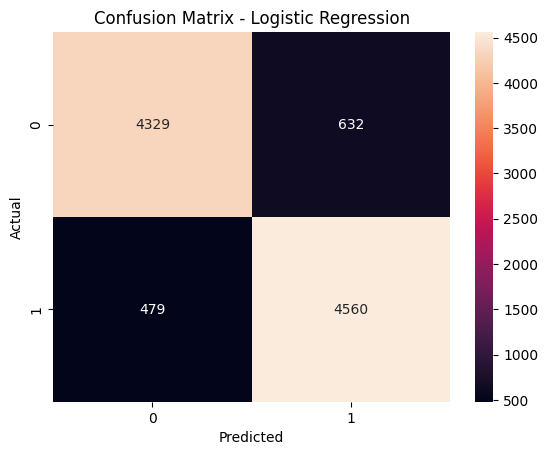

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Model** **Accuracy** **Comparison**

This graph compares the performance of different machine learning models.

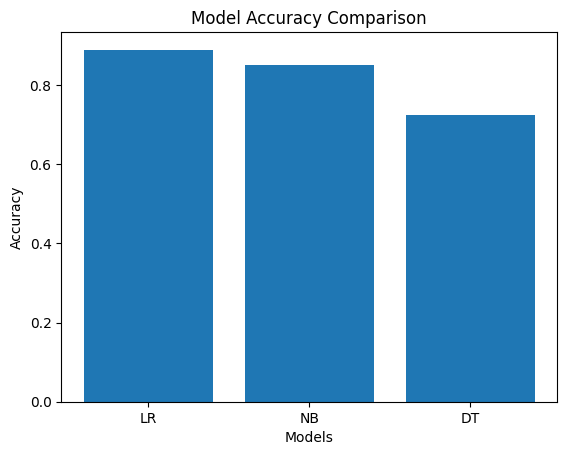

In [41]:
import matplotlib.pyplot as plt

models = ['LR', 'NB', 'DT']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

**Conclusion**

In this project, we successfully built an end-to-end Sentiment Analysis system using NLP and Machine Learning techniques.

We applied preprocessing steps such as lowercasing, stopword removal, and lemmatization to clean the text data.

Both Bag of Words and TF-IDF were used for feature engineering, and TF-IDF provided better performance by capturing important words.

Among all models, Logistic Regression achieved the best performance with around 89% accuracy and balanced precision-recall.

This shows that linear models perform effectively for text classification tasks.